In [ ]:
# 导入库
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [ ]:
# 读取 JSON 文件
data_path = Path("A_data.json")

with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"数据类型: {type(raw_data)}")
print(f"样本数量: {len(raw_data)}")

数据类型: <class 'list'>
样本数量: 251


In [ ]:
# 看第一条样本长什么样
first_sample = raw_data[0]

print("第一条记录的顶层字段：")
print(first_sample.keys())

第一条记录的顶层字段：
dict_keys(['GUID', 'conductivity', 'temperature', 'RUN_ID', 'RUN_TYPE', 'timestamp', 'pH', 'electrolyte', 'electrochemistry'])


In [ ]:
# 查看第一条样本的关键信息
print("GUID:", first_sample.get("GUID"))
print("conductivity:", first_sample.get("conductivity"))
print("pH:", first_sample.get("pH"))
print("temperature:", first_sample.get("temperature"))
print("RUN_ID:", first_sample.get("RUN_ID"))
print("RUN_TYPE:", first_sample.get("RUN_TYPE"))
print("timestamp:", first_sample.get("timestamp"))

GUID: {CB4B9CC2-CDBD-FE26-E788-729AF26C8A85}
conductivity: 111.2
pH: 8.55
temperature: 21.9
RUN_ID: AML07142019eimnsd
RUN_TYPE: production
timestamp: 7/14/2019,4:25:04 PM


In [ ]:
# 检查嵌套字段结构
print("electrolyte 字段：")
print(first_sample["electrolyte"].keys())

print("\nelectrolyte -> volumes:")
print(first_sample["electrolyte"]["volumes"])

print("\nelectrolyte -> source molalities:")
print(first_sample["electrolyte"]["source molalities"])

print("\nelectrolyte -> source densities:")
print(first_sample["electrolyte"]["source densities"])

electrolyte 字段：
dict_keys(['volumes', 'source molalities', 'source densities'])

electrolyte -> volumes:
{'water': 0.3, 'Na2SO4': 2.2, 'LiNO3': 0.5, 'Li2SO4': 2.6, 'NaNO3': 0.3, 'NaClO4': 1.1}

electrolyte -> source molalities:
{'water': 0.0, 'Na2SO4': 1.5, 'LiNO3': 7.02, 'Li2SO4': 3.01, 'NaNO3': 10.03, 'NaClO4': 16.03}

electrolyte -> source densities:
{'water': 1.0, 'Na2SO4': 1.16, 'LiNO3': 1.21, 'Li2SO4': 1.22, 'NaNO3': 1.37, 'NaClO4': 1.66}


In [ ]:
# 检查电化学数据结构
print("electrochemistry 字段：")
print(first_sample["electrochemistry"].keys())

ec = first_sample["electrochemistry"]

print("\n数组长度检查：")
print("len(i) =", len(ec["i"]))
print("len(V) =", len(ec["V"]))
print("len(t) =", len(ec["t"]))

print("\nderived_quantities:")
print(ec.get("derived_quantities", {}))

electrochemistry 字段：
dict_keys(['i', 'V', 't', 'test_name', 'derived_quantities'])

数组长度检查：
len(i) = 601
len(V) = 601
len(t) = 601

derived_quantities:
{'TAFEL CATHODE V': 1.670057, 'TAFEL ANODE V': -0.938493, '1mA/cm^2 CATHODE V': 1.568029, '1mA/cm^2 ANODE V': -0.868941}


In [ ]:
# 做一个最基础的数据质量检查
bad_samples = []

for idx, sample in enumerate(raw_data):
    try:
        ec = sample["electrochemistry"]
        if not (len(ec["i"]) == len(ec["V"]) == len(ec["t"])):
            bad_samples.append((idx, sample.get("GUID"), "电化学数组长度不一致"))
    except Exception as e:
        bad_samples.append((idx, sample.get("GUID"), str(e)))

print(f"异常样本数: {len(bad_samples)}")
bad_samples[:10]

异常样本数: 0


[]

In [ ]:
# 先整理出一个“基础表”
base_rows = []

for sample in raw_data:
    row = {
        "GUID": sample.get("GUID"),
        "conductivity": sample.get("conductivity"),
        "pH": sample.get("pH"),
        "temperature": sample.get("temperature"),
        "RUN_ID": sample.get("RUN_ID"),
        "RUN_TYPE": sample.get("RUN_TYPE"),
        "timestamp": sample.get("timestamp"),
        "test_name": sample.get("electrochemistry", {}).get("test_name"),
    }
    base_rows.append(row)

df_base = pd.DataFrame(base_rows)

print(df_base.shape)
df_base.head()

(251, 8)


,GUID,conductivity,pH,temperature,RUN_ID,RUN_TYPE,timestamp,test_name
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},111.2,8.55,21.9,AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},109.6,8.25,21.6,AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},85.9,8.80,21.8,AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},162.9,8.18,21.5,AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},156.5,8.29,21.3,AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment


In [ ]:
# 看缺失值情况
df_base.isnull().sum()

GUID            0
conductivity    0
pH              0
temperature     0
RUN_ID          0
RUN_TYPE        0
timestamp       0
test_name       0
dtype: int64

In [ ]:
# 看基础统计量
df_base.describe(include="all")

,GUID,conductivity,pH,temperature,RUN_ID,RUN_TYPE,timestamp,test_name
count,251,251.000000,251.000000,251.000000,251,251,251,251
unique,251,NaN,NaN,NaN,21,1,251,1
top,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},NaN,NaN,NaN,A08092019ythtqw,production,"7/14/2019,4:25:04 PM",fast_assessment
freq,1,NaN,NaN,NaN,35,251,1,251
mean,NaN,133.306215,7.690677,22.163347,NaN,NaN,NaN,NaN
std,NaN,33.866618,1.041018,0.734310,NaN,NaN,NaN,NaN
min,NaN,11.320000,5.210000,20.400000,NaN,NaN,NaN,NaN
25%,NaN,115.250000,6.655000,21.800000,NaN,NaN,NaN,NaN
50%,NaN,142.400000,8.210000,22.100000,NaN,NaN,NaN,NaN
75%,NaN,155.750000,8.470000,22.600000,NaN,NaN,NaN,NaN


In [ ]:
# 把 electrolyte 里的 volumes / molality / density 展开成建模表格
# 人话：把“乱七八糟的JSON配方”变成“可以建模的表格特征”

In [ ]:
# 先确认有哪些组分名
all_volume_keys = set()
all_molality_keys = set()
all_density_keys = set()

for sample in raw_data:
    elec = sample.get("electrolyte", {})
    all_volume_keys.update(elec.get("volumes", {}).keys())
    all_molality_keys.update(elec.get("source molalities", {}).keys())
    all_density_keys.update(elec.get("source densities", {}).keys())

print("volumes keys:", sorted(all_volume_keys))
print("molality keys:", sorted(all_molality_keys))
print("density keys:", sorted(all_density_keys))

volumes keys: ['Li2SO4', 'LiClO4', 'LiNO3', 'Na2SO4', 'NaBr', 'NaClO4', 'NaNO3', 'water']
molality keys: ['Li2SO4', 'LiClO4', 'LiNO3', 'Na2SO4', 'NaBr', 'NaClO4', 'NaNO3', 'water']
density keys: ['Li2SO4', 'LiClO4', 'LiNO3', 'Na2SO4', 'NaBr', 'NaClO4', 'NaNO3', 'water']


In [ ]:
# 定义一个样本展开函数 把嵌套 JSON 里的配方字段拉平成一行
def flatten_sample(sample):
    row = {
        "GUID": sample.get("GUID"),
        "conductivity": sample.get("conductivity"),
        "pH": sample.get("pH"),
        "temperature": sample.get("temperature"),
        "RUN_ID": sample.get("RUN_ID"),
        "RUN_TYPE": sample.get("RUN_TYPE"),
        "timestamp": sample.get("timestamp"),
        "test_name": sample.get("electrochemistry", {}).get("test_name"),
    }
    
    electrolyte = sample.get("electrolyte", {})
    
    volumes = electrolyte.get("volumes", {})
    molalities = electrolyte.get("source molalities", {})
    densities = electrolyte.get("source densities", {})
    
    for k, v in volumes.items():
        row[f"vol_{k}"] = v
        
    for k, v in molalities.items():
        row[f"molality_{k}"] = v
        
    for k, v in densities.items():
        row[f"density_{k}"] = v
    
    return row

In [18]:
# 展开全部样本
rows = [flatten_sample(sample) for sample in raw_data]
df_formula = pd.DataFrame(rows)

print(df_formula.shape)
df_formula.head()

(251, 32)


,GUID,conductivity,pH,temperature,RUN_ID,RUN_TYPE,timestamp,test_name,vol_water,vol_Na2SO4,...,density_LiNO3,density_Li2SO4,density_NaNO3,density_NaClO4,vol_NaBr,molality_NaBr,density_NaBr,vol_LiClO4,molality_LiClO4,density_LiClO4
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},111.2,8.55,21.9,AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment,0.3,2.2,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},109.6,8.25,21.6,AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment,0.0,1.1,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},85.9,8.80,21.8,AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment,2.9,0.0,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},162.9,8.18,21.5,AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment,0.4,0.3,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},156.5,8.29,21.3,AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment,2.2,0.0,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# 检查是否有缺失列
df_formula.isnull().sum().sort_values(ascending=False).head(30)

molality_LiClO4    180
density_LiClO4     180
molality_NaBr      180
vol_NaBr           180
vol_LiClO4         180
density_NaBr       180
molality_Na2SO4    148
vol_Na2SO4         148
density_Na2SO4     148
molality_LiNO3     117
vol_LiNO3          117
vol_Li2SO4         117
density_LiNO3      117
density_Li2SO4     117
molality_Li2SO4    117
vol_NaNO3          109
density_NaNO3      109
molality_NaClO4    109
vol_NaClO4         109
molality_NaNO3     109
density_NaClO4     109
vol_water            0
molality_water       0
test_name            0
conductivity         0
GUID                 0
pH                   0
temperature          0
RUN_ID               0
RUN_TYPE             0
dtype: int64

In [20]:
# 把配方相关缺失值补成 0
formula_cols = [c for c in df_formula.columns if c.startswith("vol_") or c.startswith("molality_") or c.startswith("density_")]

df_formula[formula_cols] = df_formula[formula_cols].fillna(0)

df_formula[formula_cols].isnull().sum().sum()

np.int64(0)

In [21]:
# 检查体积特征
volume_cols = [c for c in df_formula.columns if c.startswith("vol_")]

df_formula["total_volume"] = df_formula[volume_cols].sum(axis=1)

df_formula[["total_volume"] + volume_cols].head()


,total_volume,vol_water,vol_Na2SO4,vol_LiNO3,vol_Li2SO4,vol_NaNO3,vol_NaClO4,vol_NaBr,vol_LiClO4
0,7.0,0.3,2.2,0.5,2.6,0.3,1.1,0.0,0.0
1,7.0,0.0,1.1,1.1,3.2,0.6,1.0,0.0,0.0
2,7.0,2.9,0.0,0.6,3.3,0.1,0.1,0.0,0.0
3,7.0,0.4,0.3,1.3,0.1,4.6,0.3,0.0,0.0
4,7.0,2.2,0.0,1.7,0.1,0.9,2.1,0.0,0.0


In [22]:
# 看总体积分布
df_formula["total_volume"].describe()

count    2.510000e+02
mean     7.000000e+00
std      2.972414e-16
min      7.000000e+00
25%      7.000000e+00
50%      7.000000e+00
75%      7.000000e+00
max      7.000000e+00
Name: total_volume, dtype: float64

In [23]:
# 构造体积分数特征
for col in volume_cols:
    frac_col = col.replace("vol_", "frac_")
    df_formula[frac_col] = np.where(
        df_formula["total_volume"] > 0,
        df_formula[col] / df_formula["total_volume"],
        0
    )

frac_cols = [c for c in df_formula.columns if c.startswith("frac_")]
df_formula[frac_cols].head()

,frac_water,frac_Na2SO4,frac_LiNO3,frac_Li2SO4,frac_NaNO3,frac_NaClO4,frac_NaBr,frac_LiClO4
0,0.042857,0.314286,0.071429,0.371429,0.042857,0.157143,0.0,0.0
1,0.000000,0.157143,0.157143,0.457143,0.085714,0.142857,0.0,0.0
2,0.414286,0.000000,0.085714,0.471429,0.014286,0.014286,0.0,0.0
3,0.057143,0.042857,0.185714,0.014286,0.657143,0.042857,0.0,0.0
4,0.314286,0.000000,0.242857,0.014286,0.128571,0.300000,0.0,0.0


In [24]:
# 检查体积分数是否加和为 1
df_formula["frac_sum"] = df_formula[frac_cols].sum(axis=1)
df_formula["frac_sum"].describe()

count    2.510000e+02
mean     1.000000e+00
std      4.915167e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: frac_sum, dtype: float64

In [25]:
# 构造几个简单但有用的派生特征

# 非水组分总体积
non_water_volume_cols = [c for c in volume_cols if c != "vol_water"]
df_formula["non_water_total_volume"] = df_formula[non_water_volume_cols].sum(axis=1)

# 盐的数量（体积 > 0 的组分数，不算水）
df_formula["num_active_solutes"] = (df_formula[non_water_volume_cols] > 0).sum(axis=1)

# 水含量占比
if "vol_water" in df_formula.columns:
    df_formula["water_fraction"] = np.where(
        df_formula["total_volume"] > 0,
        df_formula["vol_water"] / df_formula["total_volume"],
        0
    )
else:
    df_formula["water_fraction"] = 0

df_formula[["total_volume", "non_water_total_volume", "num_active_solutes", "water_fraction"]].head()

,total_volume,non_water_total_volume,num_active_solutes,water_fraction
0,7.0,6.7,5,0.042857
1,7.0,7.0,5,0.000000
2,7.0,4.1,4,0.414286
3,7.0,6.6,5,0.057143
4,7.0,4.8,4,0.314286


In [26]:
# 先筛出一个“基础建模表”
target_cols = ["conductivity", "pH"]
meta_cols = ["GUID", "RUN_ID", "RUN_TYPE", "timestamp", "test_name"]
basic_feature_cols = volume_cols + frac_cols + ["total_volume", "non_water_total_volume", "num_active_solutes", "water_fraction"]

df_model_base = df_formula[meta_cols + target_cols + basic_feature_cols].copy()

print(df_model_base.shape)
df_model_base.head()

(251, 27)


,GUID,RUN_ID,RUN_TYPE,timestamp,test_name,conductivity,pH,vol_water,vol_Na2SO4,vol_LiNO3,...,frac_LiNO3,frac_Li2SO4,frac_NaNO3,frac_NaClO4,frac_NaBr,frac_LiClO4,total_volume,non_water_total_volume,num_active_solutes,water_fraction
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment,111.2,8.55,0.3,2.2,0.5,...,0.071429,0.371429,0.042857,0.157143,0.0,0.0,7.0,6.7,5,0.042857
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment,109.6,8.25,0.0,1.1,1.1,...,0.157143,0.457143,0.085714,0.142857,0.0,0.0,7.0,7.0,5,0.000000
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment,85.9,8.80,2.9,0.0,0.6,...,0.085714,0.471429,0.014286,0.014286,0.0,0.0,7.0,4.1,4,0.414286
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment,162.9,8.18,0.4,0.3,1.3,...,0.185714,0.014286,0.657143,0.042857,0.0,0.0,7.0,6.6,5,0.057143
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment,156.5,8.29,2.2,0.0,1.7,...,0.242857,0.014286,0.128571,0.300000,0.0,0.0,7.0,4.8,4,0.314286


In [28]:
# 检查目标变量缺失
df_model_base[target_cols].isnull().sum()

conductivity    0
pH              0
dtype: int64

In [29]:
# 保存一份中间结果
df_model_base.to_csv("model_base_features.csv", index=False, encoding="utf-8-sig")
print("已保存: model_base_features.csv")

已保存: model_base_features.csv


In [ ]:
# 第一问
# 把“电化学曲线（i / V / t）”变成“稳定性指标 + 电化学特征”
'''
为刻画电解液的电化学稳定性，本文基于电流-电压-时间曲线数据，提取统计特征及关键电化学参数（如Tafel电位和特定电流密度对应电位），并进一步构造稳定性窗口指标，实现从原始电化学曲线到结构化特征的转换。
曲线统计特征
    I_mean
    I_std
    I_abs_mean
    V_range
动态特征
    dVdt_mean
    dVdt_std
核心电化学指标
    tafel_window
    one_mA_window
'''

In [35]:
# 先写一个单样本特征提取函数
def safe_trapezoid(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    
    if len(y) < 2 or len(x) < 2:
        return np.nan
    
    dx = np.diff(x)
    avg_y = (y[:-1] + y[1:]) / 2
    return np.sum(avg_y * dx)


def extract_echem_features(sample):
    ec = sample.get("electrochemistry", {})
    derived = ec.get("derived_quantities", {})
    
    i_arr = np.array(ec.get("i", []), dtype=float)
    V_arr = np.array(ec.get("V", []), dtype=float)
    t_arr = np.array(ec.get("t", []), dtype=float)
    
    feat = {
        "GUID": sample.get("GUID")
    }
    
    # ---------- 基本合法性 ----------
    if len(i_arr) == 0 or len(V_arr) == 0 or len(t_arr) == 0:
        feat["echem_valid"] = 0
        return feat
    
    if not (len(i_arr) == len(V_arr) == len(t_arr)):
        feat["echem_valid"] = 0
        return feat
    
    feat["echem_valid"] = 1
    feat["n_points"] = len(i_arr)
    
    # ---------- 基础统计 ----------
    feat["V_max"] = np.max(V_arr)
    feat["V_min"] = np.min(V_arr)
    feat["V_range"] = feat["V_max"] - feat["V_min"]
    
    feat["I_max"] = np.max(i_arr)
    feat["I_min"] = np.min(i_arr)
    feat["I_abs_max"] = np.max(np.abs(i_arr))
    feat["I_mean"] = np.mean(i_arr)
    feat["I_abs_mean"] = np.mean(np.abs(i_arr))
    feat["I_std"] = np.std(i_arr)
    
    feat["t_total"] = t_arr[-1] - t_arr[0]
    
    # ---------- 曲线面积 ----------
    feat["area_abs_I_t"] = safe_trapezoid(np.abs(i_arr), t_arr)
    feat["area_I_t"] = safe_trapezoid(i_arr, t_arr)
    
    # ---------- 电压对时间斜率粗特征 ----------
    if len(t_arr) > 1:
        dV_dt = np.diff(V_arr) / np.diff(t_arr)
        feat["dVdt_mean"] = np.mean(dV_dt)
        feat["dVdt_abs_mean"] = np.mean(np.abs(dV_dt))
        feat["dVdt_std"] = np.std(dV_dt)
    else:
        feat["dVdt_mean"] = np.nan
        feat["dVdt_abs_mean"] = np.nan
        feat["dVdt_std"] = np.nan
    
    # ---------- 电流分段统计 ----------
    feat["pos_current_ratio"] = np.mean(i_arr > 0)
    feat["neg_current_ratio"] = np.mean(i_arr < 0)
    feat["zero_current_ratio"] = np.mean(i_arr == 0)
    
    # ---------- 基于 derived_quantities 的关键特征 ----------
    tafel_cathode = derived.get("TAFEL CATHODE V", np.nan)
    tafel_anode = derived.get("TAFEL ANODE V", np.nan)
    cathode_1mA = derived.get("1mA/cm^2 CATHODE V", np.nan)
    anode_1mA = derived.get("1mA/cm^2 ANODE V", np.nan)
    
    feat["TAFEL_CATHODE_V"] = tafel_cathode
    feat["TAFEL_ANODE_V"] = tafel_anode
    feat["ONE_mA_CATHODE_V"] = cathode_1mA
    feat["ONE_mA_ANODE_V"] = anode_1mA
    
    # ---------- 稳定性窗口 ----------
    if pd.notnull(tafel_cathode) and pd.notnull(tafel_anode):
        feat["tafel_window"] = tafel_cathode - tafel_anode
    else:
        feat["tafel_window"] = np.nan
    
    if pd.notnull(cathode_1mA) and pd.notnull(anode_1mA):
        feat["one_mA_window"] = cathode_1mA - anode_1mA
    else:
        feat["one_mA_window"] = np.nan
    
    return feat

In [36]:
# 对全部样本提取电化学特征
echem_rows = [extract_echem_features(sample) for sample in raw_data]
df_echem = pd.DataFrame(echem_rows)

print(df_echem.shape)
df_echem.head()

(251, 27)


,GUID,echem_valid,n_points,V_max,V_min,V_range,I_max,I_min,I_abs_max,I_mean,...,dVdt_std,pos_current_ratio,neg_current_ratio,zero_current_ratio,TAFEL_CATHODE_V,TAFEL_ANODE_V,ONE_mA_CATHODE_V,ONE_mA_ANODE_V,tafel_window,one_mA_window
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},1,601,1.980906,-1.445513,3.426419,111.111111,-111.111111,111.111111,-2.142725,...,0.969740,0.467554,0.532446,0.0,1.670057,-0.938493,1.568029,-0.868941,2.608550,2.436970
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},1,601,2.061609,-1.460748,3.522357,111.111111,-111.111111,111.111111,-2.142725,...,1.005380,0.467554,0.532446,0.0,1.703081,-0.966088,1.595291,-0.893570,2.669169,2.488861
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},1,601,1.897312,-1.451685,3.348997,111.111111,-111.111111,111.111111,-2.142725,...,0.980429,0.467554,0.532446,0.0,1.625920,-0.929020,1.528615,-0.788655,2.554940,2.317270
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},1,601,2.104969,-1.529029,3.633998,111.111111,-111.111111,111.111111,-2.142725,...,1.037324,0.467554,0.532446,0.0,1.748925,-1.017221,1.648280,-0.832859,2.766146,2.481139
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},1,601,2.130672,-1.694967,3.825639,111.111111,-111.111111,111.111111,-2.142725,...,1.068299,0.467554,0.532446,0.0,1.754464,-1.011217,1.653924,-0.815276,2.765681,2.469200


In [37]:
# 检查有效样本
df_echem["echem_valid"].value_counts(dropna=False)

echem_valid
1    251
Name: count, dtype: int64

In [ ]:
#  看缺失
df_echem.isnull().sum().sort_values(ascending=False)

GUID                  0
echem_valid           0
n_points              0
V_max                 0
V_min                 0
V_range               0
I_max                 0
I_min                 0
I_abs_max             0
I_mean                0
I_abs_mean            0
I_std                 0
t_total               0
area_abs_I_t          0
area_I_t              0
dVdt_mean             0
dVdt_abs_mean         0
dVdt_std              0
pos_current_ratio     0
neg_current_ratio     0
zero_current_ratio    0
TAFEL_CATHODE_V       0
TAFEL_ANODE_V         0
ONE_mA_CATHODE_V      0
ONE_mA_ANODE_V        0
tafel_window          0
one_mA_window         0
dtype: int64

In [39]:
# 看关键特征分布
key_cols = [
    "tafel_window",
    "one_mA_window",
    "V_range",
    "I_abs_mean",
    "area_abs_I_t"
]

df_echem[key_cols].describe()

,tafel_window,one_mA_window,V_range,I_abs_mean,area_abs_I_t
count,251.000000,251.000000,251.000000,2.510000e+02,2.510000e+02
mean,2.513431,2.294681,3.433046,4.523387e+01,2.712950e+03
std,0.387056,0.325120,0.491293,7.119624e-15,4.556559e-13
min,1.624802,1.486424,2.148211,4.523387e+01,2.712950e+03
25%,2.517685,2.136699,3.416106,4.523387e+01,2.712950e+03
50%,2.669972,2.433795,3.624857,4.523387e+01,2.712950e+03
75%,2.730725,2.512874,3.721538,4.523387e+01,2.712950e+03
max,3.031585,2.783795,4.234235,4.523387e+01,2.712950e+03


In [40]:
# 和前面的表合并
df_all = df_model_base.merge(df_echem, on="GUID", how="left")

print(df_all.shape)
df_all.head()

(251, 53)


,GUID,RUN_ID,RUN_TYPE,timestamp,test_name,conductivity,pH,vol_water,vol_Na2SO4,vol_LiNO3,...,dVdt_std,pos_current_ratio,neg_current_ratio,zero_current_ratio,TAFEL_CATHODE_V,TAFEL_ANODE_V,ONE_mA_CATHODE_V,ONE_mA_ANODE_V,tafel_window,one_mA_window
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment,111.2,8.55,0.3,2.2,0.5,...,0.969740,0.467554,0.532446,0.0,1.670057,-0.938493,1.568029,-0.868941,2.608550,2.436970
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment,109.6,8.25,0.0,1.1,1.1,...,1.005380,0.467554,0.532446,0.0,1.703081,-0.966088,1.595291,-0.893570,2.669169,2.488861
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment,85.9,8.80,2.9,0.0,0.6,...,0.980429,0.467554,0.532446,0.0,1.625920,-0.929020,1.528615,-0.788655,2.554940,2.317270
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment,162.9,8.18,0.4,0.3,1.3,...,1.037324,0.467554,0.532446,0.0,1.748925,-1.017221,1.648280,-0.832859,2.766146,2.481139
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment,156.5,8.29,2.2,0.0,1.7,...,1.068299,0.467554,0.532446,0.0,1.754464,-1.011217,1.653924,-0.815276,2.765681,2.469200


In [41]:
# 检查关键列是否成功合并
check_cols = [
    "conductivity",
    "pH",
    "tafel_window",
    "one_mA_window",
    "V_range"
]

df_all[check_cols].head()

,conductivity,pH,tafel_window,one_mA_window,V_range
0,111.2,8.55,2.608550,2.436970,3.426419
1,109.6,8.25,2.669169,2.488861,3.522357
2,85.9,8.80,2.554940,2.317270,3.348997
3,162.9,8.18,2.766146,2.481139,3.633998
4,156.5,8.29,2.765681,2.469200,3.825639


In [42]:
# 保存
df_all.to_csv("model_with_echem_features.csv", index=False, encoding="utf-8-sig")

In [ ]:
# 综合性能指标构造
'''
把 conductivity + pH + 电化学稳定性
合成一个统一评分：Score
指标            越大越好？
conductivity	✅ 是
tafel_window	✅ 是
one_mA_window	✅ 是
pH偏离度	❌ 越小越好

So 统一方向 + 标准化

人话 算Score 导电率就是傻逼一个
'''

In [ ]:
# PART1     定义目标 pH
pH_target = 7.0

In [44]:
# 构造 pH 偏离度
df_all["pH_deviation"] = np.abs(df_all["pH"] - pH_target)

In [45]:
# PART2 选择用于评分的核心指标
score_features = [
    "conductivity",
    "tafel_window",
    "one_mA_window",
    "pH_deviation"
]

In [46]:
# PART3 标准化
df_score = df_all.copy()

for col in score_features:
    min_val = df_score[col].min()
    max_val = df_score[col].max()
    
    if max_val > min_val:
        df_score[f"{col}_norm"] = (df_score[col] - min_val) / (max_val - min_val)
    else:
        df_score[f"{col}_norm"] = 0

In [47]:
# PART4 方向统一
df_score["pH_score"] = 1 - df_score["pH_deviation_norm"]
df_score["cond_score"] = df_score["conductivity_norm"]
df_score["tafel_score"] = df_score["tafel_window_norm"]
df_score["window_score"] = df_score["one_mA_window_norm"]

In [48]:
# 加权综合评分
# 方法1（主推荐）：均权
df_score["Score_equal"] = (
    df_score["cond_score"] +
    df_score["tafel_score"] +
    df_score["window_score"] +
    df_score["pH_score"]
) / 4

# 方法2（进阶加分）：强调稳定性

w_cond = 0.3
w_tafel = 0.3
w_window = 0.2
w_pH = 0.2

df_score["Score_weighted"] = (
    w_cond * df_score["cond_score"] +
    w_tafel * df_score["tafel_score"] +
    w_window * df_score["window_score"] +
    w_pH * df_score["pH_score"]
)

In [49]:
# PART6 看评分结果
df_score[["Score_equal", "Score_weighted"]].describe()

,Score_equal,Score_weighted
count,251.000000,251.000000
mean,0.616031,0.620817
std,0.130391,0.131128
min,0.270202,0.272399
25%,0.507963,0.501770
50%,0.636730,0.647133
75%,0.711068,0.719780
max,0.854767,0.845502


In [ ]:
# 找最优配方
df_score.sort_values("Score_weighted", ascending=False).head(10)

,GUID,RUN_ID,RUN_TYPE,timestamp,test_name,conductivity,pH,vol_water,vol_Na2SO4,vol_LiNO3,...,conductivity_norm,tafel_window_norm,one_mA_window_norm,pH_deviation_norm,pH_score,cond_score,tafel_score,window_score,Score_equal,Score_weighted
139,{EC26DA69-4463-675F-E863-979C9E08C2A5},AML09032019awzhtx,production,"9/3/2019,3:51:45 PM",fast_assessment,150.7,7.04,0.0,1.0,0.0,...,0.740674,0.876208,0.813815,0.011628,0.988372,0.740674,0.876208,0.813815,0.854767,0.845502
173,{CC26D5CD-C0BC-1B09-7171-4A1A9361B4D3},AML09052019ekmtsp,production,"9/5/2019,2:36:29 PM",fast_assessment,119.7,6.50,0.3,0.1,0.0,...,0.575938,0.998872,0.997884,0.189922,0.810078,0.575938,0.998872,0.997884,0.845693,0.834035
164,{38DD30DA-BC59-E86C-E991-EE1AEB42A133},AML09052019ekmtsp,production,"9/5/2019,9:57:35 AM",fast_assessment,148.2,7.17,0.4,0.3,0.0,...,0.727389,0.898207,0.792359,0.062016,0.937984,0.727389,0.898207,0.792359,0.838985,0.833747
170,{6A788641-3118-E177-B468-8DA2C9186A15},AML09052019ekmtsp,production,"9/5/2019,1:20:08 PM",fast_assessment,112.2,6.64,0.0,0.0,0.0,...,0.536082,1.000000,0.982965,0.135659,0.864341,0.536082,1.000000,0.982965,0.845847,0.830286
157,{658EAE98-541B-1F7A-950E-6FE2A77C33E5},AML09042019nanizt,production,"9/4/2019,9:11:16 PM",fast_assessment,162.1,7.15,2.2,0.4,0.0,...,0.801254,0.826366,0.761916,0.054264,0.945736,0.801254,0.826366,0.761916,0.833818,0.829817
46,{C728CD3D-8F64-3AC1-255C-2BDE9394431E},A08082019uigkul,production,"8/8/2019,11:12:33 PM",fast_assessment,170.5,7.54,1.0,0.0,0.0,...,0.845892,0.827032,0.817021,0.205426,0.794574,0.845892,0.827032,0.817021,0.821130,0.824196
48,{A0A3756C-1996-1342-9DE2-C26476ED0DC2},A08082019uigkul,production,"8/8/2019,11:54:38 PM",fast_assessment,165.7,7.62,0.0,0.0,0.0,...,0.820385,0.846422,0.842825,0.236434,0.763566,0.820385,0.846422,0.842825,0.818299,0.821320
55,{B6BBEE56-6A44-E2C5-A640-FE532DF4CF73},A08082019uigkul,production,"8/9/2019,2:18:02 AM",fast_assessment,173.4,6.17,0.0,0.0,0.0,...,0.861303,0.841833,0.867683,0.317829,0.682171,0.861303,0.841833,0.867683,0.813247,0.820911
159,{CB7F26B2-AF22-42B0-998C-2F49B1B96C12},AML09042019nanizt,production,"9/4/2019,10:00:42 PM",fast_assessment,156.6,7.41,1.8,0.6,0.0,...,0.772027,0.846417,0.827644,0.155039,0.844961,0.772027,0.846417,0.827644,0.822762,0.820054
162,{82057D2E-FE98-5629-A6F4-FCD1925EA014},AML09042019nanizt,production,"9/4/2019,11:39:54 PM",fast_assessment,168.0,6.55,0.6,0.1,0.0,...,0.832607,0.858623,0.713585,0.170543,0.829457,0.832607,0.858623,0.713585,0.808568,0.815977


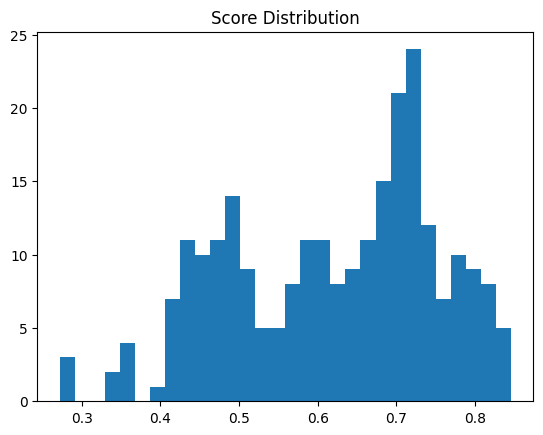

In [51]:
# PART7 可视化
import matplotlib.pyplot as plt

plt.hist(df_score["Score_weighted"], bins=30)
plt.title("Score Distribution")
plt.show()

In [ ]:
# 指标分析情况

df_score.sort_values("Score_weighted", ascending=False).head(10)
df_score["Score_weighted"].describe()
df_all[["tafel_window","one_mA_window","area_abs_I_t"]].describe()

,tafel_window,one_mA_window,area_abs_I_t
count,251.000000,251.000000,2.510000e+02
mean,2.513431,2.294681,2.712950e+03
std,0.387056,0.325120,4.556559e-13
min,1.624802,1.486424,2.712950e+03
25%,2.517685,2.136699,2.712950e+03
50%,2.669972,2.433795,2.712950e+03
75%,2.730725,2.512874,2.712950e+03
max,3.031585,2.783795,2.712950e+03


In [ ]:
# 第二问